# <mark style="display:block; background:#d1c4e9; color:#1a1a1a; padding:6px 12px; border-radius:4px">1주차 · 인기 있는 것을 모두에게 추천한다</mark>

오늘은 추천 알고리즘을 하나도 쓰지 않습니다.

가장 많이 팔린 종목 10개를 골라서 300명 모두에게 똑같이 보여 주는 것이 전부입니다.

이렇게 만든 목록을 **기준점(baseline)** 이라고 부릅니다.

---

## <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1 · 개념 — 추천이란 무엇인가  ⏱ 10분 안팎</mark>

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.1 왜 기준점이 필요한가  `[PPT]`</mark>

앞으로 10주 동안 여러 추천 모델을 배웁니다.

그 모델들이 정말 쓸모가 있는지 판단하려면 비교할 대상이 필요합니다.

"우리 모델의 정확도가 30%입니다"라는 말만 들으면 그게 좋은 건지 나쁜 건지 알 수 없습니다.

오늘 만든 기준점이 20%였다면 30%는 의미 있는 발전이고, 기준점이 이미 35%였다면 그 모델은 오히려 손해입니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.2 오늘 할 일  `[PPT]`</mark>

1. 데이터 세 개(종목, 투자자, 거래 기록)를 열어서 어떻게 생겼는지 확인합니다.
2. 가장 많이 담긴 종목 10개를 세어 그래프로 그립니다.
3. 그 10개를 모두에게 추천했을 때 얼마나 맞히는지 점수를 냅니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.3 오늘 쓰는 도구  `[PPT]`</mark>

코드를 쓰기 전에, 오늘 빌려 쓸 도구 세 개를 알아 둡니다.

1. **pandas (판다스)** — 표를 다루는 도구
   - 엑셀 시트를 파이썬에서 다룬다고 생각하면 됩니다.
   - `items.csv` 같은 파일을 읽어 표로 만들고, 세고, 정렬하는 일을 합니다.
   - 앞으로 10주 내내 씁니다.
2. **matplotlib (맷플롯립)** — 그래프를 그리는 도구
   - 숫자를 막대 · 선 · 점으로 그려 줍니다.
   - 오늘은 "가장 많이 담긴 종목 10개"를 막대그래프로 그릴 때 씁니다.
   - 숫자만 늘어놓으면 안 보이던 쏠림이 그래프로는 한눈에 보입니다.
3. **recsys.py** — 우리가 직접 만든 도구 상자
   - 남이 만든 것이 아니라 이 수업을 위해 만든 파일입니다.
   - 데이터 읽기 · 나누기 · 점수 재기를 모든 주차가 똑같이 하도록 모아 두었습니다.

---

## <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2 · 실습 — 데이터를 열어 본다  ⏱ 10분 안팎</mark>

추천을 만들려면 재료가 있어야 합니다.

오늘 쓰는 재료는 세 종류이고, 아래 용어만 알면 충분합니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.1 오늘 나오는 말  `[PPT]`</mark>

1. **EDA (이디에이, 탐색적 데이터 분석 · Exploratory Data Analysis)**
   - 모델을 만들기 **전에** 데이터가 어떻게 생겼는지 눈으로 확인하는 일입니다.
   - 요리로 치면 재료를 냉장고에서 꺼내 펼쳐 놓고 상태를 살피는 단계입니다.
   - 오늘 하는 것은 그중 가장 기초입니다.
     - 앞 몇 줄 보기
     - 개수 세기
     - 많이 나온 것 세기
     - 그래프로 보기
2. **종목 (item)**
   - 살 수 있는 상품 하나하나를 말합니다. 여기서는 주식과 ETF 100개입니다.
   - 종목마다 이런 정보가 붙어 있습니다.
     - **티커 (ticker)** — 종목 고유 코드입니다. 한국은 숫자 6자리(`035420` = NAVER), 미국은 알파벳(`SCHD`).
     - **ETF** — 여러 종목을 한 바구니에 담아 통째로 사고파는 상품입니다. "미국 대형주 500개 묶음" 같은 것입니다.
     - **자산군 (asset_class)** — `ETF` 인지 개별 `주식` 인지 구분합니다.
     - **섹터 (sector)** — 어느 분야인지입니다. 반도체 · 배당 · 바이오 · 게임 · 리츠 등.
     - **위험도 (risk_level)** — 1~5 숫자입니다. 클수록 원금을 잃을 수 있는 폭이 큽니다.
3. **투자자 (user)**
   - 서비스를 쓰는 사람입니다. 여기서는 300명입니다.
   - **성향 (persona)** — 안정형 · 성장형 · 공격형 셋 중 하나입니다.
     - 단, 이 성향은 **모델에 넣지 않습니다.** 실제 서비스에는 이런 라벨이 없다고 가정합니다.
4. **상호작용 (interaction)**
   - 누가 · 언제 · 어떤 종목에 · 무엇을 했는지의 기록입니다.
   - 추천시스템이 먹고 사는 데이터가 바로 이것입니다.
   - 행동은 세 가지입니다.
     - **view** — 봤다
     - **like** — 관심 등록했다
     - **buy** — 샀다

이번 실습에서는 이 세 파일을 열어서 실제로 어떻게 생겼는지만 확인합니다.

#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · sys.path</mark>

파이썬은 `import recsys` 를 만나면 **정해진 폴더 목록을 순서대로 뒤져서** `recsys.py` 를 찾습니다.

`sys.path` 가 바로 그 "뒤질 폴더 목록"입니다.

- `sys.path.insert(0, ".")` 에서 `0` 은 **맨 앞자리**라는 뜻입니다.
  - 목록 맨 앞에 넣으면 제일 먼저 찾습니다.
  - `"."` 은 **지금 이 폴더**를 가리키는 약속된 기호입니다.
- 아래 준비 셀에 비슷한 줄이 두 개인 이유는 **노트북을 어디서 열었는지 모르기 때문**입니다.
  - `notebooks` 폴더에서 열었다면 → `"."` 가 맞습니다.
  - 프로젝트 맨 위에서 열었다면 → `"notebooks"` 가 맞습니다.
  - 둘 다 넣어 두면 어느 쪽에서 열어도 `recsys.py` 를 찾습니다.

In [1]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.
import os
import sys

print("지금 노트북이 열려 있는 폴더")
print("  ", os.getcwd())

print()
print(f"파이썬이 import 할 때 뒤지는 폴더는 모두 {len(sys.path)}곳입니다.")
print("맨 앞 3곳만 보면:")
for 순서, 폴더 in enumerate(sys.path[:3]):
    보이기 = 폴더 if 폴더 else "(빈 칸 = 지금 폴더)"
    if len(보이기) > 50:
        보이기 = "..." + 보이기[-47:]
    print(f"  {순서}. {보이기}")

print()
print("↓ 아래 '준비' 셀을 실행한 뒤, 이 셀을 다시 실행해 보세요.")
print("  맨 앞(0번)에 우리 폴더가 새로 끼어든 것이 보입니다.")

지금 노트북이 열려 있는 폴더
   /Users/hong/workspaces/recsys/notebooks

파이썬이 import 할 때 뒤지는 폴더는 모두 5곳입니다.
맨 앞 3곳만 보면:
  0. ...ython.framework/Versions/3.12/lib/python312.zip
  1. ...s/Python.framework/Versions/3.12/lib/python3.12
  2. ...mework/Versions/3.12/lib/python3.12/lib-dynload

↓ 아래 '준비' 셀을 실행한 뒤, 이 셀을 다시 실행해 보세요.
  맨 앞(0번)에 우리 폴더가 새로 끼어든 것이 보입니다.


In [2]:
# 준비 — 필요한 도구를 불러옵니다.
# recsys.py 는 모든 주차가 함께 쓰는 도구 상자입니다. 데이터를 읽는 방법, 데이터를 나누는 방법,
# 점수를 재는 방법이 여기에 한 번만 적혀 있습니다. 주차마다 채점 방식이 달라지면 점수를 비교할 수
# 없기 때문에, 모든 노트북이 이 파일을 가져다 씁니다.
import sys

sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import recsys

print("준비 완료")

준비 완료


In [3]:
# 그래프의 한글이 깨지지 않도록 글꼴을 지정합니다.
# 운영체제마다 들어 있는 한글 글꼴이 다릅니다. 그래서 "이 컴퓨터에 실제로 깔려 있는 글꼴"을
# 먼저 확인하고, 후보 중에서 있는 것을 골라 씁니다.
from matplotlib import font_manager

설치된_글꼴 = {f.name for f in font_manager.fontManager.ttflist}

한글_글꼴_후보 = [
    "AppleGothic",      # 맥
    "Malgun Gothic",    # 윈도우 (맑은 고딕)
    "NanumGothic",      # 나눔고딕 - 리눅스에 직접 설치한 경우
    "NanumBarunGothic",
]

쓸_글꼴 = None
for 후보 in 한글_글꼴_후보:
    if 후보 in 설치된_글꼴:
        쓸_글꼴 = 후보
        break

if 쓸_글꼴:
    matplotlib.rcParams["font.family"] = 쓸_글꼴
    print(f"한글 글꼴: {쓸_글꼴}")
else:
    print("한글 글꼴을 찾지 못했습니다. 그래프의 한글이 네모(□)로 보일 수 있습니다.")
    print("윈도우라면 보통 'Malgun Gothic' 이 있습니다. Colab 이라면 아래를 실행하세요.")
    print("  !apt-get install -y fonts-nanum && rm -rf ~/.cache/matplotlib")

# 글꼴을 바꾸면 마이너스 기호가 깨지는 경우가 있어 함께 꺼 둡니다.
matplotlib.rcParams["axes.unicode_minus"] = False

한글 글꼴: AppleGothic


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.2 파일 세 개를 연다</mark>

우리가 다룰 데이터는 세 개입니다.

1. `items.csv`
   - 팔고 있는 종목 목록입니다.
   - 종목 이름, 티커, 자산군(ETF인지 개별 주식인지), 섹터, 위험도가 적혀 있습니다.
2. `users.csv`
   - 투자자 목록입니다.
3. `interactions.csv`
   - 누가 언제 어떤 종목을 봤고(view), 관심 등록했고(like), 샀는지(buy)에 대한 기록입니다.
   - 추천시스템이 실제로 먹고 사는 데이터가 바로 이것입니다.

**티커(ticker) = 종목 고유 코드**

주식이나 ETF를 짧게 부르는 번호/약자입니다.

이름은 길고 겹치기 쉬우니 코드로 구분합니다.

#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 언패킹 (unpacking)</mark>

아래 셀을 읽기 전에 문법 하나만 보고 갑니다.

파이썬은 값을 **여러 개 한꺼번에** 돌려줄 수 있습니다.

받을 때는 왼쪽에 그 개수만큼 이름을 나란히 적습니다.

- `recsys.load()` 는 파일 3개를 읽어서 **3개를 돌려줍니다.**
  - 그래서 아래 셀에서 이름 3개로 나눠 받습니다.
  - `items` · `users` · `inter` 는 파일 안에 적힌 이름이 아니라, **우리가 붙인 변수 이름**입니다.
- **순서가 전부입니다.**
  - 이름은 마음대로 지어도 되지만, 순서가 어긋나면 엉뚱한 것이 조용히 들어갑니다.
  - 여기서는 `종목 → 투자자 → 거래기록` 순서입니다.

In [4]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

a, b = 1, 2
print(a, b)

# 3개도 됩니다. 순서대로 들어갑니다.
과일, 색깔, 개수 = "사과", "빨강", 3
print(과일, 색깔, 개수)

# 개수가 안 맞으면 오류가 납니다. 아래 주석(#)을 지우고 실행해 보세요.
# p, q = 1, 2, 3

1 2
사과 빨강 3


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · f-문자열 (f-string)</mark>

문자열 앞에 `f` 를 붙이면 중괄호 `{}` 안에 값을 그대로 끼워 넣을 수 있습니다.

- `{개수}` — 변수 값이 그 자리에 들어갑니다.
- `{개수:,}` — 콜론 뒤는 **모양 지정**입니다. `,` 는 천 단위 쉼표를 뜻합니다.
- 아래 셀에서는 `{len(items):,}` 처럼 **계산과 모양 지정을 한꺼번에** 씁니다.

In [5]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

건수 = 8086

print(f"거래 {건수}건")        # 그냥 넣기
print(f"거래 {건수:,}건")      # 콜론 뒤 , 는 천 단위 쉼표

종목 = "NAVER"
print(f"{종목} 의 글자 수는 {len(종목)} 입니다")   # 안에서 계산도 된다

거래 8086건
거래 8,086건
NAVER 의 글자 수는 5 입니다


In [6]:
items, users, inter = recsys.load()

print(f"종목   {len(items):,}개")
print(f"투자자 {len(users):,}명")
print(f"거래   {len(inter):,}건")
print(f"기간   {inter['ts'].min().date()} ~ {inter['ts'].max().date()}")

종목   100개
투자자 300명
거래   8,086건
기간   2025-08-31 ~ 2026-08-30


In [7]:
items.head()

,item_id,name,ticker,market,asset_class,sector,risk_level,theme
0,I001,ACE 미국배당다우존스,402970,KR,ETF,배당,2,배당
1,I002,TIGER 미국배당다우존스,458730,KR,ETF,배당,2,배당
2,I003,KODEX 미국배당다우존스,489250,KR,ETF,배당,2,배당
3,I004,Schwab US Dividend Equity ETF,SCHD,US,ETF,배당,2,배당
4,I005,Vanguard High Dividend Yield ETF,VYM,US,ETF,배당,2,배당


In [8]:
inter.head()

,user_id,item_id,ts,event
0,U0245,I043,2025-08-31 10:00:00,view
1,U0055,I032,2025-09-03 12:00:00,like
2,U0055,I008,2025-09-04 11:00:00,view
3,U0198,I084,2025-09-09 15:00:00,view
4,U0198,I090,2025-09-10 00:00:00,like


---

## <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3 · 개념 — 어떻게 채점할 것인가  ⏱ 10분 안팎</mark>

여기서 잠깐 멈춥니다.

코드를 더 쓰기 전에, 만든 추천이 좋은지 나쁜지 **재는 방법**을 먼저 정해야 합니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.1 오늘 나오는 말  `[PPT]`</mark>

1. **기준점 (baseline)**
   - 가장 단순한 방법으로 만든 비교 대상입니다.
   - 새 모델이 기준점보다 못하면 그 모델은 쓸 이유가 없습니다.
2. **학습 구간 / 채점 구간**
   - 기록을 시간으로 잘라, **앞부분으로 추천을 만들고 뒷부분으로 채점**합니다.
   - 여기서는 이렇게 나눕니다.
     - **학습 구간** — 앞의 11개월
     - **채점 구간** — 마지막 1개월
   - 미래를 미리 보고 추천하면 반칙입니다. 이 이야기는 3주차에 자세히 다룹니다.
3. **Recall@10**
   - 오늘 쓸 점수입니다.
   - 채점 구간에서 그 사람이 **실제로 담은 종목** 중, 내가 준 **10개 안에 몇 개**가 있었는지의 비율입니다.
   - 계산은 이렇게 합니다. `[PPT]`
     - 그 사람이 4개를 담았고 그중 1개를 맞혔다 → `1 / 4 = 0.25`
     - 이것을 채점 대상 투자자 전원에 대해 평균 낸다

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.2 과거로 배우고 미래로 채점한다  `[PPT]`</mark>

> **PPT 소재** — 12개월 막대를 그어 앞 11개월(학습) / 뒤 1개월(채점)로 자르는 그림 1장.

점수를 매기려면 정답이 필요합니다.

그런데 추천의 정답은 "이 사람이 앞으로 무엇을 담을 것인가"이므로, 우리가 가진 기록을 시간으로 잘라서 **앞부분으로 추천을 만들고 뒷부분으로 채점**합니다.

여기서는 마지막 1개월을 채점용으로 떼어 놓습니다.

그 앞의 11개월이 학습 구간입니다.

왜 시간으로 잘라야 하는지는 3주차에 자세히 다룹니다.

지금은 "미래를 미리 보면 반칙"이라는 것만 기억하면 됩니다.

In [9]:
train, test, cut = recsys.split_by_time(inter)

print(f"기준 시점: {cut.date()}")
print(f"학습 구간(이 시점 이전) {len(train):,}건 · 투자자 {train['user_id'].nunique()}명")
print(f"채점 구간(이 시점 이후) {len(test):,}건 · 투자자 {test['user_id'].nunique()}명")

기준 시점: 2026-07-30
학습 구간(이 시점 이전) 7,095건 · 투자자 285명
채점 구간(이 시점 이후) 991건 · 투자자 266명


---

## <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4 · 실습 — 인기순으로 추천하고 점수를 낸다  ⏱ 10분 안팎</mark>

이제 추천을 만들고 점수를 재 봅니다.

알고리즘은 하나도 쓰지 않습니다. 가장 많이 팔린 10개를 모두에게 똑같이 보여 주는 것이 전부입니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.1 오늘 나오는 말  `[PPT]`</mark>

1. **인기순 추천**
   - 학습 구간에서 거래가 많았던 순서대로 위에서 10개를 자릅니다.
   - 누가 오든 같은 목록입니다.
     - 백화점 입구의 "이달의 베스트 10" 포스터와 같습니다.
     - 포스터는 누가 지나가든 내용이 바뀌지 않습니다.
2. **이미 담은 종목 빼기**
   - 이미 산 물건을 다시 추천하는 것은 추천이 아닙니다.
   - 그래서 그 사람이 학습 구간에서 담았던 종목은 목록에서 뺍니다. `recsys.take()` 가 해 줍니다.
3. **개인화 (personalization)**
   - 사람마다 다른 목록을 주는 것입니다.
   - **오늘은 하지 않습니다.**
     - 마지막에 성향이 정반대인 두 사람의 목록을 나란히 놓고 봅니다.
     - 왜 이것을 추천이라 부르기 어려운지 직접 확인합니다.
   - 개인화는 2주차부터 시작합니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.2 가장 많이 담긴 종목 10개</mark>

학습 구간에서 종목별로 거래 건수를 세면 그것이 곧 인기 순위표입니다.

`value_counts()` 한 줄이면 끝납니다.

다만 `I042` 같은 종목 번호는 사람이 읽을 수 없으므로, 종목 이름을 붙여서 봅니다.

#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 딕셔너리 (dictionary)</mark>

**"이것을 주면 저것을 돌려주는" 표**입니다. 중괄호로 만듭니다.

- 왼쪽을 **키(key)**, 오른쪽을 **값(value)** 이라 부릅니다.
- 리스트는 순서(0, 1, 2…)로 찾지만, 딕셔너리는 **내가 정한 키**로 찾습니다.
- 아래에서 만들 `name_of` 는 종목번호를 주면 종목이름을 돌려주는 딕셔너리입니다.
  - `name_of["I001"]` → `ACE 미국배당다우존스`
  - 종목이 100개면 짝도 100개입니다.

In [10]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

나이 = {"철수": 20, "영희": 22}

print(나이["철수"])        # 키를 주면 값이 나온다
print(len(나이))           # 짝이 몇 개인지

나이["민수"] = 25          # 새로 넣기
print(나이)

print("철수" in 나이)      # 그 키가 있는지 확인

20
2
{'철수': 20, '영희': 22, '민수': 25}
True


In [11]:
# 종목 번호를 이름으로 바꿔 주는 표를 만들어 둡니다. 앞으로 계속 씁니다.
# 한 줄로 이어 붙이면 짧지만 중간에 무엇이 만들어지는지 보이지 않습니다. 한 단계씩 나눠 봅니다.
items_by_id = items.set_index("item_id")   # 행 이름을 item_id 로 바꾼다   → DataFrame
name_column = items_by_id["name"]          # 이름 열 하나만 꺼낸다          → Series
name_of = name_column.to_dict()            # {종목번호: 종목이름} 사전       → dict

print(f"items_by_id  {type(items_by_id).__name__}  {items_by_id.shape}")
print(f"name_column  {type(name_column).__name__}  {len(name_column)}개")
print(f"name_of      {type(name_of).__name__}  예) I001 → {name_of['I001']}")

items_by_id  DataFrame  (100, 7)
name_column  Series  100개
name_of      dict  예) I001 → ACE 미국배당다우존스


In [12]:
# 학습 구간에서 종목별로 거래가 몇 번 있었는지 셉니다. 이것이 곧 인기 순위표입니다.
종목별_거래건수 = train["item_id"].value_counts()   # 많은 순으로 정렬되어 나온다
top10 = 종목별_거래건수.head(10)                     # 그중 위에서 10개만

print(f"전체 {len(종목별_거래건수)}개 종목 중 상위 10개를 골랐습니다.\n")
print(top10)

전체 100개 종목 중 상위 10개를 골랐습니다.

item_id
I042    228
I043    172
I040    148
I067    131
I068    115
I038    109
I041    103
I070    102
I006     99
I019     98
Name: count, dtype: int64


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 리스트 컴프리헨션 (list comprehension)</mark>

리스트를 만드는 짧은 문법입니다. `for` 문을 한 줄로 접은 것입니다.

- 읽는 순서가 거꾸로입니다. **뒤의 `for` 를 먼저** 보고, 앞의 식을 나중에 봅니다.
- 아래 셀의 `[name_of[i] for i in top10.index]` 는 이렇게 읽습니다.
  - **뒤** — `top10.index` 에서 하나씩 꺼내 `i` 라고 부른다
  - **앞** — 그 `i` 를 이름으로 바꿔서 모은다

In [13]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

# for 문으로 쓰면 네 줄
결과 = []
for x in [1, 2, 3]:
    결과.append(x * 10)
print(결과)

# 컴프리헨션으로 쓰면 한 줄 (결과는 똑같다)
결과2 = [x * 10 for x in [1, 2, 3]]
print(결과2)

# 조건을 붙일 수도 있습니다 — 짝수만 모으기
짝수 = [x for x in [1, 2, 3, 4, 5, 6] if x % 2 == 0]
print(짝수)

[10, 20, 30]
[10, 20, 30]
[2, 4, 6]


In [14]:
# 위 결과는 종목 번호라서 읽기 어렵습니다. 사람이 볼 수 있게 표로 정리합니다.
# 표에 넣을 열 세 개를 각각 따로 준비한 다음 마지막에 합칩니다.
종목명 = [name_of[i] for i in top10.index]
거래건수 = top10.values
비중 = [f"{c / len(train):.1%}" for c in 거래건수]

인기표 = pd.DataFrame({"종목명": 종목명, "거래건수": 거래건수, "비중": 비중})
인기표.index = range(1, 11)
인기표

,종목명,거래건수,비중
1,iShares Core MSCI EAFE ETF,228,3.2%
2,Vanguard FTSE Developed Markets ETF,172,2.4%
3,TIGER 미국S&P500,148,2.1%
4,Taiwan Semiconductor,131,1.8%
5,Invesco QQQ Trust,115,1.6%
6,Vanguard S&P 500 ETF,109,1.5%
7,ACE 미국S&P500,103,1.5%
8,KODEX 미국나스닥100,102,1.4%
9,TIGER 리츠부동산인프라,99,1.4%
10,Procter & Gamble,98,1.4%


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 슬라이싱 (slicing)</mark>

리스트를 잘라 내는 문법입니다. 대괄호 안에 콜론을 씁니다.

- 형태는 `[시작:끝:간격]` 이고, 셋 다 생략할 수 있습니다.
- **`[::-1]` 은 "간격 -1", 즉 거꾸로 훑으라는 뜻**입니다.
  - 뒤집기 관용구로 통째로 외워 두면 됩니다.

In [15]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

목록 = ["가", "나", "다", "라"]

print(목록[:2])      # 앞에서 2개
print(목록[2:])      # 3번째부터 끝까지
print(목록[-1])      # 맨 뒤 하나
print(목록[::-1])    # 통째로 뒤집기

['가', '나']
['다', '라']
라
['라', '다', '나', '가']


In [16]:
# 그래프에 넣을 값을 준비합니다. 바로 앞 셀에서 만든 종목명·거래건수를 그대로 씁니다.
# barh 는 막대를 아래에서 위로 쌓으므로, 1위가 맨 위에 오게 하려면 순서를 뒤집어야 합니다.
이름_역순 = 종목명[::-1]     # [::-1] 은 "거꾸로" 라는 뜻입니다
값_역순 = 거래건수[::-1]

print(f"맨 아래에 그려질 종목: {이름_역순[0]}  (10위)")
print(f"맨 위에 그려질 종목:  {이름_역순[-1]}  (1위)")

맨 아래에 그려질 종목: Procter & Gamble  (10위)
맨 위에 그려질 종목:  iShares Core MSCI EAFE ETF  (1위)


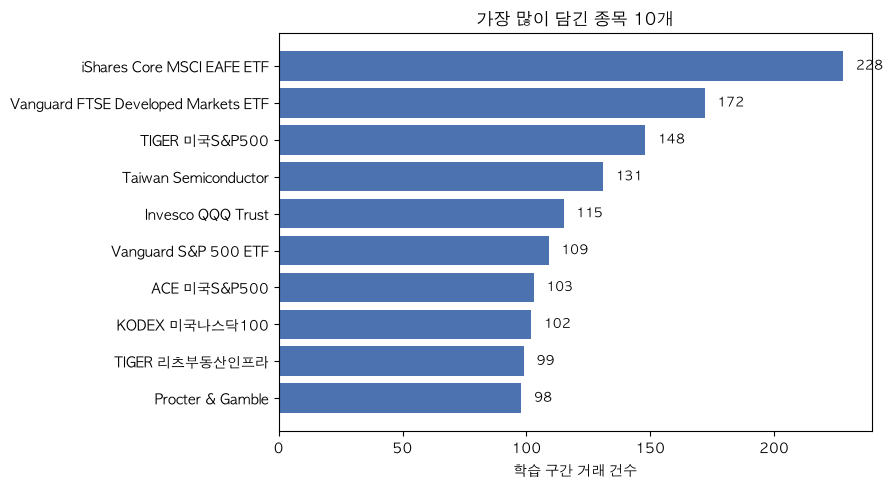

In [17]:
# 그래프를 그립니다. subplots 부터 show 까지는 한 셀에 붙어 있어야 그림이 한 번만 나옵니다.
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(이름_역순, 값_역순, color="#4C72B0")
ax.set_xlabel("학습 구간 거래 건수")
ax.set_title("가장 많이 담긴 종목 10개")

# 막대 끝에 숫자를 적어 줍니다.
for y, v in enumerate(값_역순):
    ax.text(v + 5, y, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

상위 10개가 전체 거래에서 차지하는 비중을 보면, 특정 종목 몇 개에 거래가 몰려 있다는 것을 알 수 있습니다.

이런 쏠림이 있기 때문에 "인기 있는 것을 그냥 보여 주기"만 해도 어느 정도는 맞습니다.

오늘 재는 점수가 0이 아닌 이유가 여기에 있습니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.3 추천 목록을 만들고 점수를 낸다</mark>

추천 함수는 아주 단순합니다.

누가 오든 인기 순위표 위에서부터 10개를 잘라서 돌려줍니다.

한 가지만 신경 씁니다.

**이미 담은 종목은 빼고** 줍니다.

이미 산 물건을 다시 추천하는 것은 추천이라고 할 수 없기 때문입니다.

그 처리는 `recsys.take()` 가 대신해 줍니다.

점수는 **Recall@10** 으로 잽니다.

채점 구간에서 그 사람이 실제로 담은 종목 중 내가 준 10개 안에 몇 개가 들어 있었는지의 비율입니다.

예를 들어 그 사람이 실제로 4개를 담았고 그중 1개를 맞혔다면 0.25입니다.

이것을 채점 대상 투자자 전원에 대해 평균 냅니다.

In [18]:
# 인기 순위표를 "종목 번호만 담은 리스트" 로 만듭니다.
인기순위_번호 = 종목별_거래건수.index   # 앞에서 만든 것을 그대로 씁니다 (많은 순 정렬)
인기순위 = list(인기순위_번호)          # Index → 파이썬 리스트

print(f"인기순위 {len(인기순위)}개 · 1위 {name_of[인기순위[0]]} · 꼴찌 {name_of[인기순위[-1]]}")


def 모두에게_같은_추천(user_id, seen):
    """누가 오든 인기 순위표에서 아직 안 담은 것 10개를 준다."""
    return recsys.take(인기순위, seen)


score, n_eval = recsys.recall_at_k(모두에게_같은_추천, train, test)
print(f"Recall@10 = {score:.4f}   (채점 대상 투자자 {n_eval}명)")

인기순위 100개 · 1위 iShares Core MSCI EAFE ETF · 꼴찌 삼성에스디에스
Recall@10 = 0.2163   (채점 대상 투자자 266명)


In [19]:
recsys.record(1, "전체 인기", score,
              note="알고리즘 없음. 인기 상위 10개를 모두에게 동일하게 추천한 기준점")

레벨 1 · 전체 인기 · Recall@10 = 0.2163


{'level': 1,
 'name': '전체 인기',
 'recall_at_10': 0.2163,
 'note': '알고리즘 없음. 인기 상위 10개를 모두에게 동일하게 추천한 기준점'}

Recall@10 이 약 0.22 라는 것은, 그 사람이 실제로 담은 종목 다섯 개 중 하나 정도를 우리가 미리 목록에 넣어 두었다는 뜻입니다.

알고리즘을 하나도 쓰지 않은 것 치고는 나쁘지 않은 숫자입니다.

그래서 이 숫자가 앞으로의 기준점이 됩니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.4 이것을 추천이라고 부를 수 있을까</mark>

성향이 정반대인 두 사람을 골라서 각자의 추천 목록을 나란히 놓아 봅니다.

한 사람은 원금을 지키는 것이 최우선인 안정형 투자자이고, 다른 한 사람은 손실을 감수하고 큰 수익을 노리는 공격형 투자자입니다.

(`users.csv` 의 성향 라벨은 **모델 입력으로 쓰지 않습니다.** 실제 서비스에는 이런 라벨이 없다고 가정하기 때문입니다.

여기서는 결과를 눈으로 확인하기 위한 용도로만 꺼내 씁니다.)

In [20]:
# 사람마다 "학습 구간에서 이미 담았던 종목들"을 사전으로 만들어 둡니다.
# 추천할 때 이미 담은 것을 빼려면 이 정보가 필요합니다.
사람별_묶음 = train.groupby("user_id")        # 투자자별로 묶는다 (아직 계산 전)  → GroupBy
사람별_종목 = 사람별_묶음["item_id"]           # 각 묶음에서 종목 번호 열만        → SeriesGroupBy

# 리스트가 아니라 집합(set)으로 만듭니다. "이미 담았나?" 를 확인할 때 집합이 훨씬 빠릅니다.
사람별_종목_집합 = 사람별_종목.apply(set)      # 묶음마다 중복을 없애 집합으로     → Series
seen_map = 사람별_종목_집합.to_dict()          # {투자자: {종목번호, ...}} 사전    → dict

예시_투자자 = list(seen_map)[0]
print(f"묶음 {사람별_묶음.ngroups}명 → 사전 {len(seen_map)}개")
print(f"예) {예시_투자자} 가 담았던 종목 {len(seen_map[예시_투자자])}개")

묶음 285명 → 사전 285개
예) U0001 가 담았던 종목 16개


In [21]:
# 성향이 정반대인 두 사람을 한 명씩 고릅니다. 채점 구간에 기록이 있어야 비교할 수 있습니다.
채점대상 = set(test["user_id"])

안정형_행 = users[users["persona"] == "안정형"]              # 안정형인 사람들만
안정형_아이디들 = 안정형_행["user_id"]                        # 그중 아이디 열만
채점가능_안정형 = [u for u in 안정형_아이디들 if u in 채점대상]  # 채점 구간에 기록이 있는 사람만
안정형 = 채점가능_안정형[0]                                   # 그중 첫 번째 한 명

공격형_행 = users[users["persona"] == "공격형"]
공격형_아이디들 = 공격형_행["user_id"]
채점가능_공격형 = [u for u in 공격형_아이디들 if u in 채점대상]
공격형 = 채점가능_공격형[0]

print(f"안정형 {안정형} (후보 {len(채점가능_안정형)}명 중 한 명)")
print(f"공격형 {공격형} (후보 {len(채점가능_공격형)}명 중 한 명)")

안정형 U0001 (후보 85명 중 한 명)
공격형 U0003 (후보 87명 중 한 명)


In [22]:
# 두 사람에게 각각 추천을 만들어서 나란히 놓고 봅니다.
목록_안정 = 모두에게_같은_추천(안정형, seen_map.get(안정형, set()))
목록_공격 = 모두에게_같은_추천(공격형, seen_map.get(공격형, set()))

# 종목 번호는 읽기 어려우니 이름으로 바꿔 둡니다.
안정_목록_이름 = [name_of[i] for i in 목록_안정]
공격_목록_이름 = [name_of[i] for i in 목록_공격]

비교 = pd.DataFrame({
    f"{안정형} (안정형)": 안정_목록_이름,
    f"{공격형} (공격형)": 공격_목록_이름,
})
비교.index = range(1, 11)
비교

,U0001 (안정형),U0003 (공격형)
1,Vanguard FTSE Developed Markets ETF,Vanguard FTSE Developed Markets ETF
2,TIGER 미국S&P500,Vanguard S&P 500 ETF
3,Taiwan Semiconductor,KODEX 미국나스닥100
4,Invesco QQQ Trust,TIGER 리츠부동산인프라
5,Vanguard S&P 500 ETF,Schwab US Dividend Equity ETF
6,ACE 미국S&P500,DB하이텍
7,KODEX 미국나스닥100,KODEX 국고채30년액티브
8,Schwab US Dividend Equity ETF,Salesforce
9,ProShares UltraPro QQQ,TIGER 은행고배당플러스TOP10
10,DB하이텍,KODEX 미국배당다우존스


In [23]:
if 목록_안정 == 목록_공격:
    print("두 사람의 추천 목록이 완전히 같습니다.")
else:
    # 열 번째까지 자리를 하나씩 비교해서, 종목이 다른 자리만 모읍니다.
    다른자리 = []
    for i in range(10):
        if 목록_안정[i] != 목록_공격[i]:
            다른자리.append(i)

    print(f"두 사람의 목록은 {len(다른자리)}자리만 다릅니다. 그것도 이미 담은 종목을 걸러낸 결과일 뿐,")
    print("추천 논리가 사람에 따라 달라진 것은 아닙니다.")
    print("서로 다른 종목:")
    for i in 다른자리:
        안정_종목 = name_of[목록_안정[i]]
        공격_종목 = name_of[목록_공격[i]]
        print(f"  {i + 1:2d}위  {안정_종목}  /  {공격_종목}")

두 사람의 목록은 9자리만 다릅니다. 그것도 이미 담은 종목을 걸러낸 결과일 뿐,
추천 논리가 사람에 따라 달라진 것은 아닙니다.
서로 다른 종목:
   2위  TIGER 미국S&P500  /  Vanguard S&P 500 ETF
   3위  Taiwan Semiconductor  /  KODEX 미국나스닥100
   4위  Invesco QQQ Trust  /  TIGER 리츠부동산인프라
   5위  Vanguard S&P 500 ETF  /  Schwab US Dividend Equity ETF
   6위  ACE 미국S&P500  /  DB하이텍
   7위  KODEX 미국나스닥100  /  KODEX 국고채30년액티브
   8위  Schwab US Dividend Equity ETF  /  Salesforce
   9위  ProShares UltraPro QQQ  /  TIGER 은행고배당플러스TOP10
  10위  DB하이텍  /  KODEX 미국배당다우존스


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.5 오늘의 마무리  `[PPT]`</mark>

원금 손실을 극도로 꺼리는 사람과 레버리지 상품까지 담는 사람에게 우리는 사실상 같은 목록을 내밀었습니다.

두 목록에 차이가 생기더라도 그것은 "이미 담은 종목을 뺐다"는 이유뿐이고, 추천의 근거 자체는 두 사람에게 똑같았습니다.

이것을 추천이라고 부를 수 있을까요?

백화점 입구에 붙은 "이달의 베스트 10" 포스터와 다를 것이 없습니다.

포스터는 누가 지나가든 내용이 바뀌지 않습니다.

**2주차에는 사람마다 다른 목록을 만듭니다.** 그 사람이 지금까지 주로 담아 온 종목을 보고, 비슷한 성격의 종목을 골라 주는 규칙을 세울 것입니다.

그리고 오늘 쓴 Recall@10 이 정확히 무엇을 재는 숫자인지, Precision 이나 NDCG 같은 다른 지표와는 무엇이 다른지 직접 계산해 봅니다.